In [1]:
!pip install tensorflow

In [2]:
import numpy as np # 데이터 구조 및 벡터 연산용
import pandas as pd #데이터 구조 및 벡터 연산용
import matplotlib.pyplot as plt #데이터 시각화. 특히 확률 분포와 혼동행렬 등에 사용됨
from sklearn.model_selection import train_test_split #데이터 훈련/테스트 분할
from sklearn.preprocessing import StandardScaler # 신경망 학습 안정화를 위한 정규화 (표준화)
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_curve, auc, roc_auc_score
)
from mpl_toolkits.mplot3d import Axes3D

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [26]:
redwine = pd.read_csv('winequality-red.csv', sep=",")
redwine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [27]:
#Q1
redwine['quality2'] = np.where(redwine['quality'] > 6.5, 'good', 'bad')
redwine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality2
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,bad
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,bad
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,bad
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,bad
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,bad


In [28]:
X=redwine.drop(['quality','quality2'],axis=1)
y = (redwine['quality2'] == 'good').astype(int)

In [29]:
#Q2
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=2039, stratify=y)

In [31]:
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.int32)
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.int32)

In [32]:
import tensorflow as tf
import random

SEED = 2039
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [39]:
layers_range = range(1, 5)  
nodes_range = range(3, 11)  

auroc_matrix = np.zeros((len(layers_range), len(nodes_range)))
failed_combinations = []  # 수렴 실패 조합 기록용

for i, layer_num in enumerate(layers_range):
    for j, node_num in enumerate(nodes_range):
        
        try:
            # 신경망 모형 구성
            model = Sequential()
            model.add(Dense(units=node_num, activation='relu', input_shape=(X_train.shape[1],)))
            
            for _ in range(layer_num - 1):
                model.add(Dense(units=node_num, activation='relu'))
            
            model.add(Dense(units=1, activation='sigmoid'))
            
            model.compile(
                optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            
            history = model.fit(
                X_train, y_train,
                epochs=1,
                batch_size=32,
                verbose=0
            )
            
            y_pred_prob = model.predict(X_test, verbose=0).flatten()
            auroc = roc_auc_score(y_test, y_pred_prob)
            final_loss = history.history['loss'][-1]
            
            # 수렴 실패 판정: loss가 NaN인 경우 (= 학습 중 error에 해당)
            if np.isnan(final_loss):
                auroc_matrix[i, j] = np.nan
                failed_combinations.append((layer_num, node_num, f'loss=NaN: 수렴 실패'))
                print(f"은닉층 {layer_num}개 / 노드 {node_num}개 → 수렴 실패 (loss=NaN)")
            else:
                auroc_matrix[i, j] = auroc
                print(f"은닉층 {layer_num}개 / 노드 {node_num}개 → AUROC: {auroc:.4f}")
        
        except Exception as e:
            # Exception 발생 = 수렴 실패 
            auroc_matrix[i, j] = np.nan
            failed_combinations.append((layer_num, node_num, str(e)))
            print(f"은닉층 {layer_num}개 / 노드 {node_num}개 → 오류 발생 (수렴 실패)")


print(f"\nAUROC Matrix:\n{np.round(auroc_matrix, 4)}")

# 수렴 실패 보고서 출력
print()
if len(failed_combinations) == 0:
    print("수렴 실패한 조합 없음: 모든 신경망이 정상적으로 수렴함.")
else:
    print("[수렴 실패 조합 보고]")
    for layer_num, node_num, error_msg in failed_combinations:
        print(f"  은닉층 {layer_num}개 / 은닉노드 {node_num}개: 수렴하지 않음")
        print(f"  사유: {error_msg}")


은닉층 1개 / 노드 3개 → AUROC: 0.5122
은닉층 1개 / 노드 4개 → AUROC: 0.5776
은닉층 1개 / 노드 5개 → AUROC: 0.5965
은닉층 1개 / 노드 6개 → AUROC: 0.6980
은닉층 1개 / 노드 7개 → AUROC: 0.4466
은닉층 1개 / 노드 8개 → AUROC: 0.5374
은닉층 1개 / 노드 9개 → AUROC: 0.6425
은닉층 1개 / 노드 10개 → AUROC: 0.4753
은닉층 2개 / 노드 3개 → AUROC: 0.7737
은닉층 2개 / 노드 4개 → AUROC: 0.6199
은닉층 2개 / 노드 5개 → AUROC: 0.7831
은닉층 2개 / 노드 6개 → AUROC: 0.4567
은닉층 2개 / 노드 7개 → AUROC: 0.3393
은닉층 2개 / 노드 8개 → AUROC: 0.6842
은닉층 2개 / 노드 9개 → AUROC: 0.4565
은닉층 2개 / 노드 10개 → AUROC: 0.3652
은닉층 3개 / 노드 3개 → AUROC: 0.6508
은닉층 3개 / 노드 4개 → AUROC: 0.4348
은닉층 3개 / 노드 5개 → AUROC: 0.4035
은닉층 3개 / 노드 6개 → AUROC: 0.7075
은닉층 3개 / 노드 7개 → AUROC: 0.3543
은닉층 3개 / 노드 8개 → AUROC: 0.6647
은닉층 3개 / 노드 9개 → AUROC: 0.3862
은닉층 3개 / 노드 10개 → AUROC: 0.4712
은닉층 4개 / 노드 3개 → AUROC: 0.3723
은닉층 4개 / 노드 4개 → AUROC: 0.1720
은닉층 4개 / 노드 5개 → AUROC: 0.7053
은닉층 4개 / 노드 6개 → AUROC: 0.3699
은닉층 4개 / 노드 7개 → AUROC: 0.7679
은닉층 4개 / 노드 8개 → AUROC: 0.6762
은닉층 4개 / 노드 9개 → AUROC: 0.6307
은닉층 4개 / 노드 10개 → AUROC: 0.5856

AUR

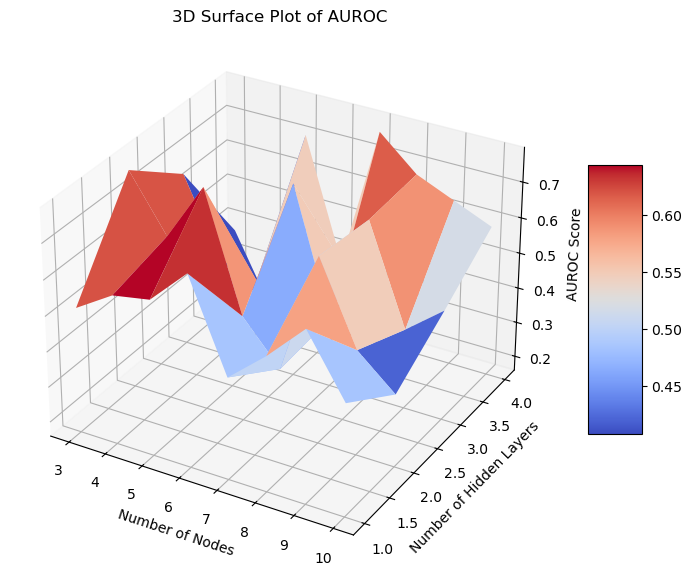

In [40]:
X_mesh, Y_mesh = np.meshgrid(list(nodes_range), list(layers_range))
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X_mesh, Y_mesh, auroc_matrix, cmap='coolwarm', edgecolor='none')
ax.set_title('3D Surface Plot of AUROC')
ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Number of Hidden Layers')
ax.set_zlabel('AUROC Score')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

In [41]:
best_idx = np.unravel_index(np.nanargmax(auroc_matrix), auroc_matrix.shape)
best_layers = list(layers_range)[best_idx[0]]
best_nodes  = list(nodes_range)[best_idx[1]]
best_auroc  = auroc_matrix[best_idx]

print(f'은닉층 수: {best_layers}개')
print(f'은닉노드: {best_nodes}개')
print(f'최적 AUROC: {best_auroc:.4f}')

은닉층 수: 2개
은닉노드: 5개
최적 AUROC: 0.7831
